In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [4]:

df = pd.read_csv(r'C:\Users\sujit\OneDrive\Desktop\House price prediction\house-price-predictor\data\train.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Missing Values:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64


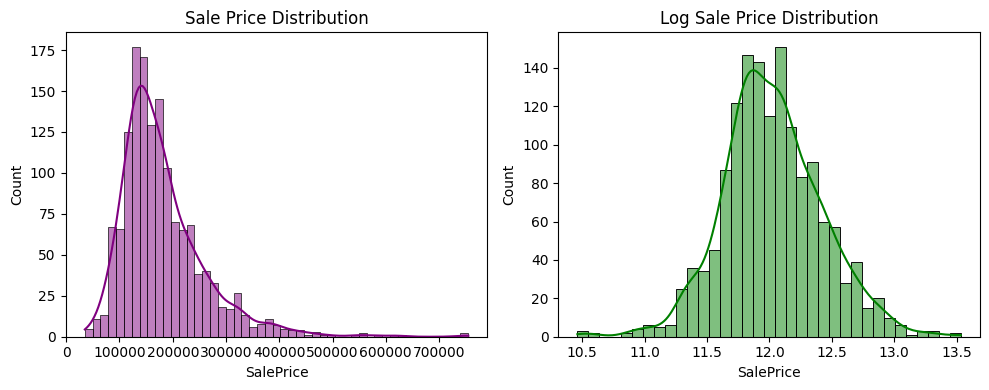

In [5]:
# Missing values பாருங்கள்
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing Values:\n", missing.head(10))

# Target variable distribution
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['SalePrice'], kde=True, color='purple')
plt.title('Sale Price Distribution')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['SalePrice']), kde=True, color='green')
plt.title('Log Sale Price Distribution')
plt.tight_layout()
plt.show()

In [9]:
import joblib
import os

# Full path கொடுங்கள்
BASE_DIR = r'C:\Users\sujit\OneDrive\Desktop\House price prediction\house-price-predictor'
src_path = os.path.join(BASE_DIR, 'src')
os.makedirs(src_path, exist_ok=True)

joblib.dump(model, os.path.join(src_path, 'house_model.pkl'))
joblib.dump(le, os.path.join(src_path, 'label_encoder.pkl'))

print("✅ Model saved!")
print("✅ Path:", os.path.join(src_path, 'house_model.pkl'))

✅ Model saved!
✅ Path: C:\Users\sujit\OneDrive\Desktop\House price prediction\house-price-predictor\src\house_model.pkl


In [7]:
X = df_model.drop('SalePrice', axis=1)
y = np.log1p(df_model['SalePrice'])  # Log transform

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model train பண்ணுங்கள்
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# Evaluate பண்ணுங்கள்
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"✅ Model Trained!")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")

✅ Model Trained!
R² Score : 0.8646
RMSE     : 0.1590


In [8]:
import joblib
import os

# src folder path
os.makedirs('../src', exist_ok=True)

joblib.dump(model, '../src/house_model.pkl')
joblib.dump(le, '../src/label_encoder.pkl')

print("✅ Model saved to src/house_model.pkl")
print("✅ Label encoder saved to src/label_encoder.pkl")

✅ Model saved to src/house_model.pkl
✅ Label encoder saved to src/label_encoder.pkl
